<a href="https://colab.research.google.com/github/vivek-bhushan/IIT-M/blob/main/W-7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# Step 1: Import libraries
import pandas as pd
from pycaret.classification import setup, create_model, evaluate_model, compare_models

# Step 2: Load dataset
df = pd.read_csv("/content/WA_Fn-UseC_-/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")
   # replace with your dataset path

# Step 3: Setup PyCaret environment
clf = setup(
    data=df,
    target='Attrition',        # assuming target column is 'Attrition'
    imputation_type='simple',  # handle missing values
    normalize=True,            # feature scaling
    remove_outliers=True,      # outlier detection
    silent=True,
    session_id=123
)

# Step 4: Train specific models
# Logistic Regression
log_reg = create_model('lr')

# Linear Regression (not typical for classification, but can be tested)
lin_reg = create_model('ridge')   # ridge regression as linear baseline

# Support Vector Machine
svm_model = create_model('svm')

# Decision Tree
dt_model = create_model('dt')

# Step 5: Evaluate each model
evaluate_model(log_reg)
evaluate_model(lin_reg)
evaluate_model(svm_model)
evaluate_model(dt_model)

# Step 6: Compare metrics
compare_models(include=['lr','ridge','svm','dt'])

RuntimeError: ('Pycaret only supports python 3.9, 3.10, 3.11. Your actual Python version: ', sys.version_info(major=3, minor=12, micro=13, releaselevel='final', serial=0), 'Please DOWNGRADE your Python version.')

In [ ]:
!pip install pycaret

# New Section

In [37]:
"""
HR Employee Attrition – Yes-class focused classification and comparison.

Models:
- Logistic Regression
- Linear SVM
- RBF SVM
- Decision Tree

Features:
- EDA and class imbalance check
- Preprocessing with ColumnTransformer (scaling + one-hot encoding)
- Class_weight="balanced" for all models
- Optional SMOTE oversampling (if imblearn is installed)
- Metrics per model: confusion matrix, accuracy, precision, recall, F1, ROC-AUC (Yes class)
- Comparison table sorted by recall and F1 for Attrition = Yes
- Threshold tuning for Logistic Regression to boost recall(Yes)
"""

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
)

# Optional: SMOTE for oversampling (if imblearn is available)
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False


DATA_FILE = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
OUTPUT_DIR = Path("output")


# -----------------------------------------------------------------------------
# Data loading and EDA
# -----------------------------------------------------------------------------
def load_data(csv_path: str = DATA_FILE):
    df = pd.read_csv(csv_path)

    print("=== Basic info ===")
    print("Shape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nDtypes:\n", df.dtypes)
    print("\nHead:\n", df.head())

    # Target encoding
    df["AttritionFlag"] = df["Attrition"].map({"Yes": 1, "No": 0})

    # Class distribution
    print("\n=== Attrition distribution ===")
    counts = df["Attrition"].value_counts()
    props = df["Attrition"].value_counts(normalize=True)
    print(pd.DataFrame({"count": counts, "proportion": props}))

    # Quick statement about imbalance
    yes_rate = props.get("Yes", 0.0)
    print(f"\nApproximate attrition rate (Yes): {yes_rate:.3f}")
    if yes_rate < 0.3:
        print("Dataset is imbalanced: 'Yes' is the minority class.")

    # Simple bar plot
    OUTPUT_DIR.mkdir(exist_ok=True)
    plt.figure(figsize=(4, 4))
    counts.plot(kind="bar", color=["tab:blue", "tab:orange"])
    plt.title("Attrition distribution")
    plt.ylabel("Employee count")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "attrition_distribution_bar.png")
    plt.close()

    # Identify column types
    cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    print("\n=== Feature types ===")
    print("Numeric columns:", len(num_cols))
    print("Categorical columns:", len(cat_cols))

    return df


def prepare_features(df: pd.DataFrame):
    # Drop obvious ID-like or useless columns if present
    drop_cols = []
    for c in ["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"]:
        if c in df.columns:
            drop_cols.append(c)

    print("\nDropping ID/constant columns:", drop_cols)

    X = df.drop(columns=["Attrition", "AttritionFlag"] + drop_cols)
    y = df["AttritionFlag"]

    cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    return X, y, num_cols, cat_cols


# -----------------------------------------------------------------------------
# Preprocessing and models
# -----------------------------------------------------------------------------
def build_preprocessor(num_cols, cat_cols):
    numeric_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(handle_unknown="ignore")

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols),
        ]
    )
    return preprocessor


def get_models():
    models = {
        "log_reg": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
        ),
        "svm_linear": LinearSVC(
            class_weight="balanced",
        ),
        "svm_rbf": SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
        ),
        "decision_tree": DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42,
        ),
    }
    return models


# -----------------------------------------------------------------------------
# Evaluation utilities
# -----------------------------------------------------------------------------
def evaluate_model(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)

    # Positive class = 1 (Attrition = Yes)
    accuracy = accuracy_score(y_test, y_pred)
    precision_pos = precision_score(y_test, y_pred, pos_label=1)
    recall_pos = recall_score(y_test, y_pred, pos_label=1)
    f1_pos = f1_score(y_test, y_pred, pos_label=1)
    cm = confusion_matrix(y_test, y_pred)

    # ROC-AUC
    if hasattr(pipeline, "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        if hasattr(pipeline, "decision_function"):
            scores = pipeline.decision_function(X_test)
            s_min, s_max = scores.min(), scores.max()
            if s_max > s_min:
                scores_scaled = (scores - s_min) / (s_max - s_min)
            else:
                scores_scaled = np.zeros_like(scores)
            roc_auc = roc_auc_score(y_test, scores_scaled)
        else:
            roc_auc = np.nan

    print(f"\n===== {name} =====")
    print("Confusion matrix (rows: true [0,1], cols: pred [0,1]):")
    print(cm)
    print(f"Accuracy:        {accuracy:.3f}")
    print(f"Precision (Yes): {precision_pos:.3f}")
    print(f"Recall (Yes):    {recall_pos:.3f}")
    print(f"F1 (Yes):        {f1_pos:.3f}")
    print(f"ROC-AUC (Yes):   {roc_auc:.3f}")

    # Brief interpretation
    if recall_pos >= 0.7:
        print("Interpretation: High recall on Yes; good at catching leavers, may sacrifice precision.")
    elif recall_pos <= 0.3:
        print("Interpretation: Low recall on Yes; risky, many leavers are missed.")
    else:
        print("Interpretation: Moderate recall on Yes; balance between missing and over-flagging leavers.")

    metrics = {
        "model": name,
        "accuracy": accuracy,
        "precision_pos": precision_pos,
        "recall_pos": recall_pos,
        "f1_pos": f1_pos,
        "roc_auc": roc_auc,
    }
    return metrics


def tune_threshold_log_reg(pipe, X_test, y_test, target_recall=0.75):
    """
    Threshold tuning for logistic regression to improve recall on Yes.
    Assumes pipe has predict_proba.
    """
    if not hasattr(pipe, "predict_proba"):
        print("\n[Threshold tuning] Pipeline has no predict_proba; skipping.")
        return

    y_proba = pipe.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

    # Find threshold with recall closest to or above target_recall
    idx = np.where(recall >= target_recall)[0]
    if len(idx) == 0:
        # Fall back to the threshold that maximizes F1
        f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[max(best_idx - 1, 0)] if best_idx > 0 else 0.5
        print(
            f"\n[Threshold tuning] Could not achieve recall >= {target_recall:.2f}; "
            "using threshold that roughly maximizes F1 instead."
        )
    else:
        best_idx = idx[0]
        best_threshold = thresholds[max(best_idx - 1, 0)]

    print(f"\n[Threshold tuning] Chosen threshold: {best_threshold:.3f}")

    # Metrics at default threshold 0.5
    y_pred_default = (y_proba >= 0.5).astype(int)
    f1_default = f1_score(y_test, y_pred_default, pos_label=1)
    recall_default = recall_score(y_test, y_pred_default, pos_label=1)
    precision_default = precision_score(y_test, y_pred_default, pos_label=1)

    # Metrics at tuned threshold
    y_pred_tuned = (y_proba >= best_threshold).astype(int)
    f1_tuned = f1_score(y_test, y_pred_tuned, pos_label=1)
    recall_tuned = recall_score(y_test, y_pred_tuned, pos_label=1)
    precision_tuned = precision_score(y_test, y_pred_tuned, pos_label=1)

    print("\n[Threshold tuning] Default vs tuned threshold:")
    print(f"Default 0.5 -> recall(Yes)={recall_default:.3f}, precision(Yes)={precision_default:.3f}, F1(Yes)={f1_default:.3f}")
    print(f"Tuned {best_threshold:.3f} -> recall(Yes)={recall_tuned:.3f}, precision(Yes)={precision_tuned:.3f}, F1(Yes)={f1_tuned:.3f}")

    # Optional: save a simple PR curve plot
    plt.figure(figsize=(5, 4))
    plt.plot(recall, precision, label="PR curve")
    plt.xlabel("Recall (Yes)")
    plt.ylabel("Precision (Yes)")
    plt.title("Precision–Recall curve (Logistic Regression)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "logreg_precision_recall_curve.png")
    plt.close()


# -----------------------------------------------------------------------------
# Main workflow
# -----------------------------------------------------------------------------
def main():
    OUTPUT_DIR.mkdir(exist_ok=True)

    # Load and prepare data
    df = load_data(DATA_FILE)
    X, y, num_cols, cat_cols = prepare_features(df)
    preprocessor = build_preprocessor(num_cols, cat_cols)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=42,
        stratify=y,
    )

    models = get_models()
    results = []

    # -------------------------------------------------------------------------
    # Train & evaluate models (no oversampling)
    # -------------------------------------------------------------------------
    print("\n=== Training models (no SMOTE) ===")
    trained_pipelines = {}

    for name, clf in models.items():
        pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", clf)])
        pipe.fit(X_train, y_train)
        trained_pipelines[name] = pipe

        metrics = evaluate_model(name, pipe, X_test, y_test)
        results.append(metrics)

    results_df = pd.DataFrame(results)
    results_df_sorted = results_df.sort_values(
        by=["recall_pos", "f1_pos"], ascending=False
    )

    print("\n===== Comparison focused on Attrition = Yes (no SMOTE) =====")
    print(results_df_sorted)

    results_df_sorted.to_csv(
        OUTPUT_DIR / "model_comparison_attrition_yes_focus_no_smote.csv",
        index=False,
    )

    # -------------------------------------------------------------------------
    # Threshold tuning for logistic regression
    # -------------------------------------------------------------------------
    if "log_reg" in trained_pipelines:
        print("\n=== Threshold tuning for Logistic Regression ===")
        tune_threshold_log_reg(trained_pipelines["log_reg"], X_test, y_test)
    else:
        print("\n[Warning] Logistic Regression pipeline not found; skipping threshold tuning.")

    # -------------------------------------------------------------------------
    # Optional: SMOTE vs no SMOTE comparison for Logistic Regression
    # -------------------------------------------------------------------------
    if SMOTE_AVAILABLE and "log_reg" in models:
        print("\n=== Logistic Regression with SMOTE vs without SMOTE ===")

        # Without SMOTE (already trained)
        pipe_no_smote = trained_pipelines["log_reg"]
        y_pred_no = pipe_no_smote.predict(X_test)
        f1_no = f1_score(y_test, y_pred_no, pos_label=1)
        recall_no = recall_score(y_test, y_pred_no, pos_label=1)

        # With SMOTE (oversample training set within imblearn pipeline)
        smote = SMOTE(random_state=42)
        log_reg = models["log_reg"]
        imb_pipe = ImbPipeline(
            steps=[
                ("preprocess", preprocessor),
                ("smote", smote),
                ("model", log_reg),
            ]
        )
        imb_pipe.fit(X_train, y_train)

        y_pred_sm = imb_pipe.predict(X_test)
        f1_sm = f1_score(y_test, y_pred_sm, pos_label=1)
        recall_sm = recall_score(y_test, y_pred_sm, pos_label=1)

        print("Without SMOTE -> recall(Yes)={:.3f}, F1(Yes)={:.3f}".format(recall_no, f1_no))
        print("With SMOTE    -> recall(Yes)={:.3f}, F1(Yes)={:.3f}".format(recall_sm, f1_sm))

        smote_comp = pd.DataFrame(
            [
                {"variant": "no_smote", "recall_pos": recall_no, "f1_pos": f1_no},
                {"variant": "with_smote", "recall_pos": recall_sm, "f1_pos": f1_sm},
            ]
        )
        print("\nSMOTE vs no SMOTE (Logistic Regression):")
        print(smote_comp)

        smote_comp.to_csv(
            OUTPUT_DIR / "logreg_smote_vs_no_smote.csv", index=False
        )
    else:
        print(
            "\n[Info] imblearn/SMOTE not available or log_reg missing; "
            "skipping SMOTE comparison."
        )


if __name__ == "__main__":
    main()

=== Basic info ===
Shape: (1470, 35)

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Dtypes:
 Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeN

In [28]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# --------------------------------------------------
# 1. Load data and basic EDA
# --------------------------------------------------
DATA_FILE = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(DATA_FILE)

print("=== Basic info ===")
print("Shape:", df.shape)

# Create numeric target: Yes -> 1, No -> 0
df["AttritionFlag"] = df["Attrition"].map({"Yes": 1, "No": 0})

# Drop ID-like / constant columns
drop_cols = [c for c in ["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"] if c in df.columns]
X = df.drop(columns=["Attrition", "AttritionFlag"] + drop_cols)
y = df["AttritionFlag"]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# --------------------------------------------------
# 3. Train-test split
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --------------------------------------------------
# 4. Preprocessing
# --------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

# --------------------------------------------------
# 5. Define 4 models (Added Ridge as Linear baseline)
# --------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Linear Regression (Ridge)": RidgeClassifier(class_weight="balanced"),
    "SVM (RBF kernel)": SVC(kernel="rbf", probability=True, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
}

# --------------------------------------------------
# 6. Train and evaluate
# --------------------------------------------------
results = []
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_yes": precision_score(y_test, y_pred, pos_label=1),
        "recall_yes": recall_score(y_test, y_pred, pos_label=1),
        "f1_yes": f1_score(y_test, y_pred, pos_label=1),
    })

results_df = pd.DataFrame(results).sort_values(by=["recall_yes", "f1_yes"], ascending=False)
print("\n===== Updated Model Comparison (4 Models) =====")
display(results_df)
results_df.to_csv(output_dir / "expanded_model_comparison.csv", index=False)

=== Basic info ===
Shape: (1470, 35)

===== Updated Model Comparison (4 Models) =====


,model,accuracy,precision_yes,recall_yes,f1_yes
0,Logistic Regression,0.764172,0.372093,0.676056,0.480000
1,Linear Regression (Ridge),0.750567,0.355556,0.676056,0.466019
2,SVM (RBF kernel),0.829932,0.478261,0.619718,0.539877
3,Decision Tree,0.780045,0.308824,0.295775,0.302158


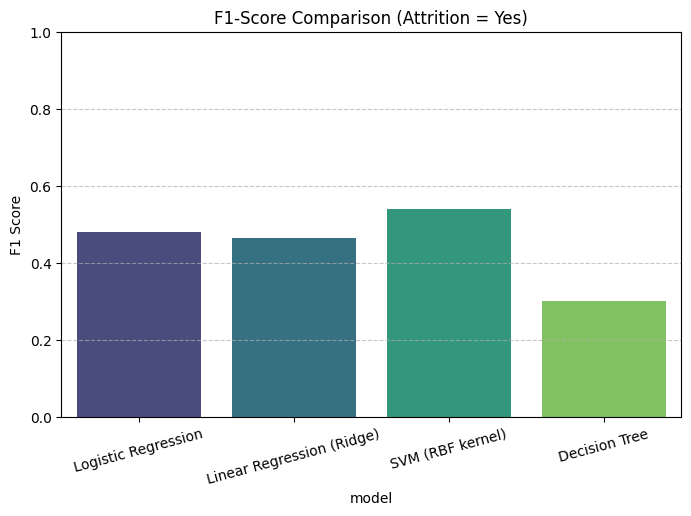

In [29]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(x='model', y='f1_yes', data=results_df, palette='viridis')
plt.title('F1-Score Comparison (Attrition = Yes)')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

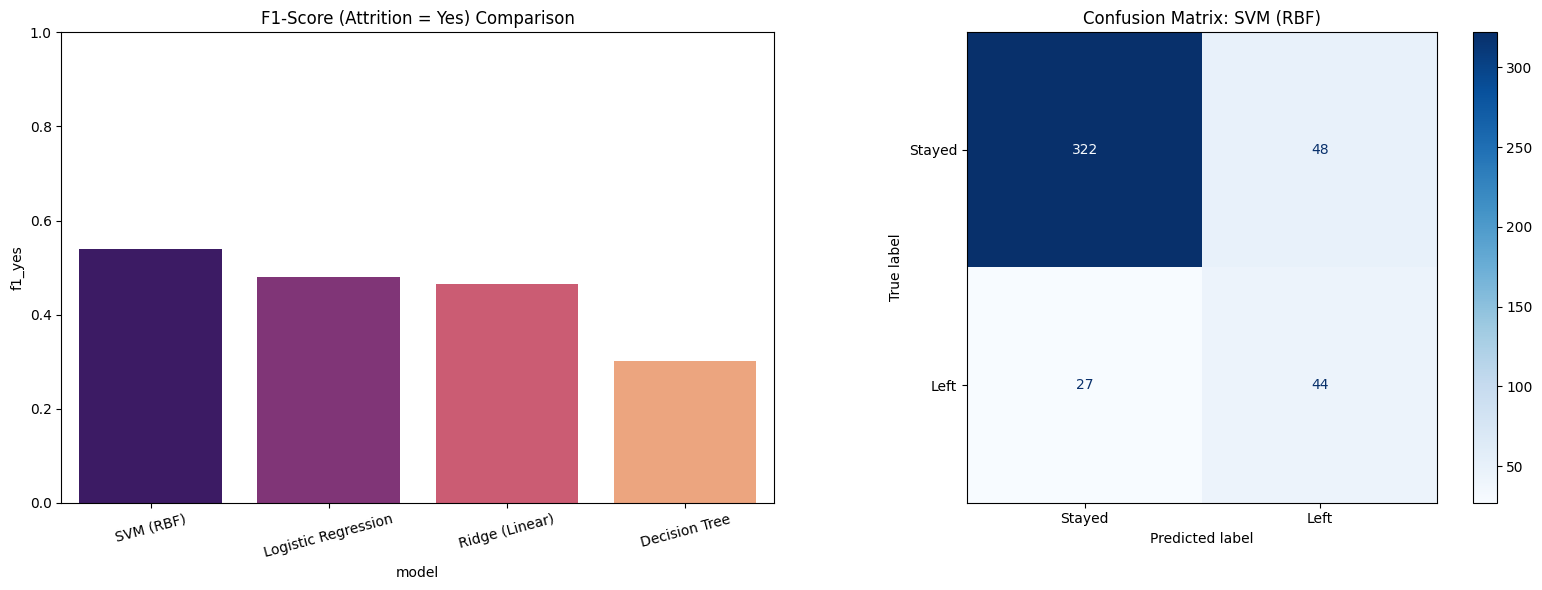


--- Detailed Performance Metrics ---


,model,accuracy,precision_yes,recall_yes,f1_yes
2,SVM (RBF),0.829932,0.478261,0.619718,0.539877
0,Logistic Regression,0.764172,0.372093,0.676056,0.480000
1,Ridge (Linear),0.750567,0.355556,0.676056,0.466019
3,Decision Tree,0.780045,0.308824,0.295775,0.302158


In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

# 1. Configuration & Data Loading
DATA_FILE = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(DATA_FILE)
df["AttritionFlag"] = df["Attrition"].map({"Yes": 1, "No": 0})

# Drop constants and IDs
drop_cols = [c for c in ["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"] if c in df.columns]
X = df.drop(columns=["Attrition", "AttritionFlag"] + drop_cols)
y = df["AttritionFlag"]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

# 4. Model Definitions (4 Models)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Ridge (Linear)": RidgeClassifier(class_weight="balanced"),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
}

# 5. Execution & Metrics Collection
results = []
trained_pipes = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    trained_pipes[name] = pipe

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_yes": precision_score(y_test, y_pred, pos_label=1),
        "recall_yes": recall_score(y_test, y_pred, pos_label=1),
        "f1_yes": f1_score(y_test, y_pred, pos_label=1),
    })

results_df = pd.DataFrame(results).sort_values(by="f1_yes", ascending=False)

# 6. Graphical Representation
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: F1 Score Comparison
sns.barplot(x='model', y='f1_yes', data=results_df, palette='magma', ax=ax[0])
ax[0].set_title('F1-Score (Attrition = Yes) Comparison')
ax[0].set_ylim(0, 1)
ax[0].tick_params(axis='x', rotation=15)

# Plot B: Confusion Matrix for Top Model (SVM RBF usually)
top_model_name = results_df.iloc[0]['model']
y_pred_top = trained_pipes[top_model_name].predict(X_test)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_top,
    display_labels=["Stayed", "Left"],
    cmap='Blues',
    ax=ax[1]
)
ax[1].set_title(f'Confusion Matrix: {top_model_name}')

plt.tight_layout()
plt.show()

print("\n--- Detailed Performance Metrics ---")
display(results_df)


Model Performance:

                 model  accuracy  precision    recall  f1_score
2                  SVM  0.829932   0.478261  0.619718  0.539877
0  Logistic Regression  0.764172   0.372093  0.676056  0.480000
1                Ridge  0.750567   0.355556  0.676056  0.466019
3        Decision Tree  0.780045   0.308824  0.295775  0.302158


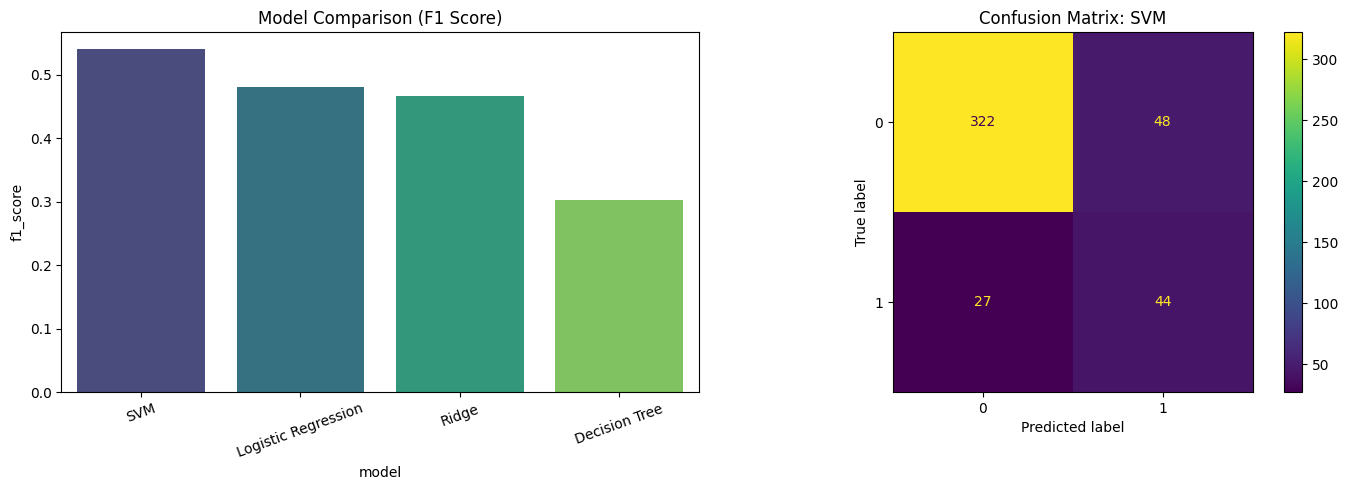

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)

# -----------------------------
# 1. Load and Prepare Data
# -----------------------------
def load_data(file_path):
    df = pd.read_csv(file_path)

    # Convert target to binary
    df["AttritionFlag"] = df["Attrition"].map({"Yes": 1, "No": 0})

    # Drop unnecessary columns
    drop_cols = ["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"]
    df = df.drop(columns=[col for col in drop_cols if col in df.columns])

    X = df.drop(columns=["Attrition", "AttritionFlag"])
    y = df["AttritionFlag"]

    return X, y


# -----------------------------
# 2. Preprocessing Pipeline
# -----------------------------
def create_preprocessor(X):
    cat_cols = X.select_dtypes(include=["object"]).columns
    num_cols = X.select_dtypes(include=[np.number]).columns

    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ])

    return preprocessor


# -----------------------------
# 3. Model Definitions
# -----------------------------
def get_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
        "Ridge": RidgeClassifier(class_weight="balanced"),
        "SVM": SVC(kernel="rbf", probability=True, class_weight="balanced"),
        "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    }


# -----------------------------
# 4. Train and Evaluate
# -----------------------------
def train_and_evaluate(models, preprocessor, X_train, X_test, y_train, y_test):
    results = []
    trained_models = {}

    for name, model in models.items():
        pipe = Pipeline([
            ("preprocess", preprocessor),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        trained_models[name] = pipe

        results.append({
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1_score": f1_score(y_test, y_pred)
        })

    results_df = pd.DataFrame(results).sort_values(by="f1_score", ascending=False)
    return results_df, trained_models


# -----------------------------
# 5. Visualization
# -----------------------------
def plot_results(results_df, best_model, X_test, y_test, trained_models):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # F1 Score Bar Plot
    sns.barplot(data=results_df, x="model", y="f1_score", palette="viridis", ax=ax[0])
    ax[0].set_title("Model Comparison (F1 Score)")
    ax[0].tick_params(axis='x', rotation=20)

    # Confusion Matrix
    y_pred = trained_models[best_model].predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[1])
    ax[1].set_title(f"Confusion Matrix: {best_model}")

    plt.tight_layout()
    plt.show()


# -----------------------------
# 6. Main Execution
# -----------------------------
def main():
    file_path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

    X, y = load_data(file_path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    preprocessor = create_preprocessor(X)
    models = get_models()

    results_df, trained_models = train_and_evaluate(
        models, preprocessor, X_train, X_test, y_train, y_test
    )

    best_model = results_df.iloc[0]["model"]

    print("\nModel Performance:\n")
    print(results_df)

    plot_results(results_df, best_model, X_test, y_test, trained_models)


if __name__ == "__main__":
    main()


Model Performance Metrics:
                 model  accuracy  precision    recall  f1_score
2                  SVM  0.829932   0.478261  0.619718  0.539877
0  Logistic Regression  0.764172   0.372093  0.676056  0.480000
1                Ridge  0.750567   0.355556  0.676056  0.466019
3        Decision Tree  0.780045   0.308824  0.295775  0.302158


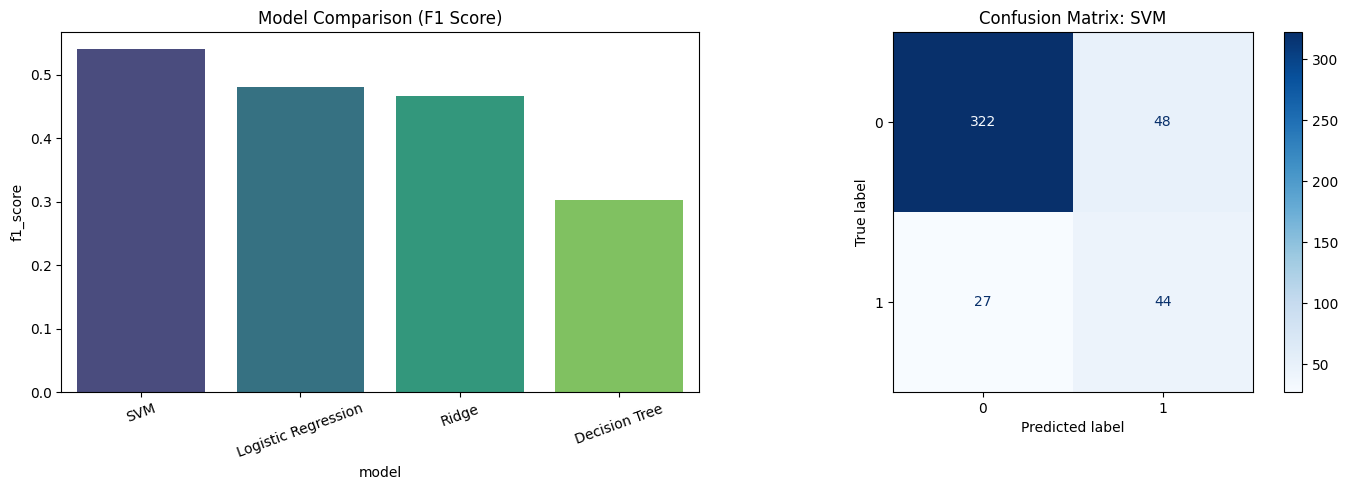

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)

# -----------------------------
# 1. Load and Prepare Data
# -----------------------------
def load_data(file_path):
    df = pd.read_csv(file_path)

    # Convert target to binary
    df["AttritionFlag"] = df["Attrition"].map({"Yes": 1, "No": 0})

    # Drop unnecessary columns
    drop_cols = ["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"]
    df = df.drop(columns=[col for col in drop_cols if col in df.columns])

    X = df.drop(columns=["Attrition", "AttritionFlag"])
    y = df["AttritionFlag"]

    return X, y

# -----------------------------
# 2. Preprocessing Pipeline
# -----------------------------
def create_preprocessor(X):
    cat_cols = X.select_dtypes(include=["object"]).columns
    num_cols = X.select_dtypes(include=[np.number]).columns

    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ])

    return preprocessor

# -----------------------------
# 3. Model Definitions
# -----------------------------
def get_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
        "Ridge": RidgeClassifier(class_weight="balanced"),
        "SVM": SVC(kernel="rbf", probability=True, class_weight="balanced"),
        "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    }

# -----------------------------
# 4. Train and Evaluate
# -----------------------------
def train_and_evaluate(models, preprocessor, X_train, X_test, y_train, y_test):
    results = []
    trained_models = {}

    for name, model in models.items():
        pipe = Pipeline([
            ("preprocess", preprocessor),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        trained_models[name] = pipe

        results.append({
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1_score": f1_score(y_test, y_pred)
        })

    results_df = pd.DataFrame(results).sort_values(by="f1_score", ascending=False)
    return results_df, trained_models

# -----------------------------
# 5. Visualization
# -----------------------------
def plot_results(results_df, best_model, X_test, y_test, trained_models):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # F1 Score Bar Plot
    sns.barplot(data=results_df, x="model", y="f1_score", palette="viridis", ax=ax[0])
    ax[0].set_title("Model Comparison (F1 Score)")
    ax[0].tick_params(axis='x', rotation=20)

    # Confusion Matrix
    y_pred = trained_models[best_model].predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[1], cmap='Blues')
    ax[1].set_title(f"Confusion Matrix: {best_model}")

    plt.tight_layout()
    plt.show()

# -----------------------------
# 6. Main Execution
# -----------------------------
def main():
    file_path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
    X, y = load_data(file_path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    preprocessor = create_preprocessor(X)
    models = get_models()

    results_df, trained_models = train_and_evaluate(
        models, preprocessor, X_train, X_test, y_train, y_test
    )

    best_model = results_df.iloc[0]["model"]

    print("\nModel Performance Metrics:")
    print(results_df)

    plot_results(results_df, best_model, X_test, y_test, trained_models)

if __name__ == "__main__":
    main()

In [33]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import f1_score

# 1. Load Data
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df["AttritionFlag"] = df["Attrition"].map({"Yes": 1, "No": 0})

df = df.drop(columns=["Attrition", "EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"], errors="ignore")

X = df.drop("AttritionFlag", axis=1)
y = df["AttritionFlag"]

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Preprocessing
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(include=np.number).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# 4. Models (simple set)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC()
}

# 5. Train + Evaluate
results = {}

for name, clf in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", clf)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    f1 = f1_score(y_test, y_pred)
    results[name] = f1

    print(f"{name} F1 Score: {f1:.3f}")

# 6. Find Best Model
best_model = max(results, key=results.get)

print("\nBest Model:", best_model)
print("Best F1 Score:", round(results[best_model], 3))

Logistic Regression F1 Score: 0.531
Decision Tree F1 Score: 0.291
SVM F1 Score: 0.315

Best Model: Logistic Regression
Best F1 Score: 0.531


In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score

# Load data
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df["AttritionFlag"] = df["Attrition"].map({"Yes": 1, "No": 0})

# Basic features (keeping it simple)
X = df[["Age", "MonthlyIncome", "DistanceFromHome"]]
y = df["AttritionFlag"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Models
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "Tree": DecisionTreeClassifier(),
    "SVM": SVC()
}

best_score = 0
best_model = ""

# Train + check
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    score = f1_score(y_test, pred)

    print(name, "F1:", round(score, 3))

    if score > best_score:
        best_score = score
        best_model = name

# Final result
print("\nBest Model:", best_model)
print("Best F1 Score:", round(best_score, 3))

Logistic F1: 0.0
Tree F1: 0.214
SVM F1: 0.0

Best Model: Tree
Best F1 Score: 0.214


Logistic F1: 0.342
Tree F1: 0.174

Best Model: Logistic
Best F1 Score: 0.342


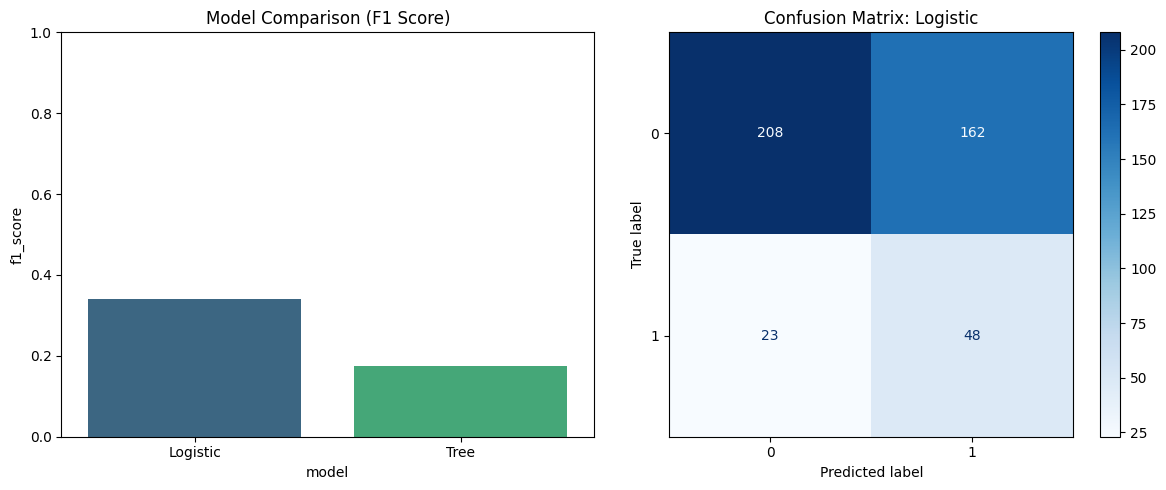

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, ConfusionMatrixDisplay

# Load data
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df["AttritionFlag"] = df["Attrition"].map({"Yes": 1, "No": 0})

# Simple features
X = df[["Age", "MonthlyIncome", "DistanceFromHome"]]
y = df["AttritionFlag"]

# Split (important: stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale data (important)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models (keep it small)
models = {
    "Logistic": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Tree": DecisionTreeClassifier(class_weight="balanced")
}

results = []
trained_models = {}
best_score = 0
best_model_name = ""

# Train and compare
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    trained_models[name] = model

    score = f1_score(y_test, pred)
    results.append({"model": name, "f1_score": score})

    print(name, "F1:", round(score, 3))

    if score > best_score:
        best_score = score
        best_model_name = name

# Final result
print("\nBest Model:", best_model_name)
print("Best F1 Score:", round(best_score, 3))

# Graphical Representation
results_df = pd.DataFrame(results)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: F1 Comparison
sns.barplot(data=results_df, x="model", y="f1_score", ax=ax[0], palette="viridis")
ax[0].set_title("Model Comparison (F1 Score)")
ax[0].set_ylim(0, 1)

# Plot 2: Confusion Matrix for Best Model
ConfusionMatrixDisplay.from_estimator(trained_models[best_model_name], X_test, y_test, ax=ax[1], cmap="Blues")
ax[1].set_title(f"Confusion Matrix: {best_model_name}")

plt.tight_layout()
plt.show()

Logistic F1: 0.342
Tree F1: 0.168

Best Model: Logistic
Best F1 Score: 0.342


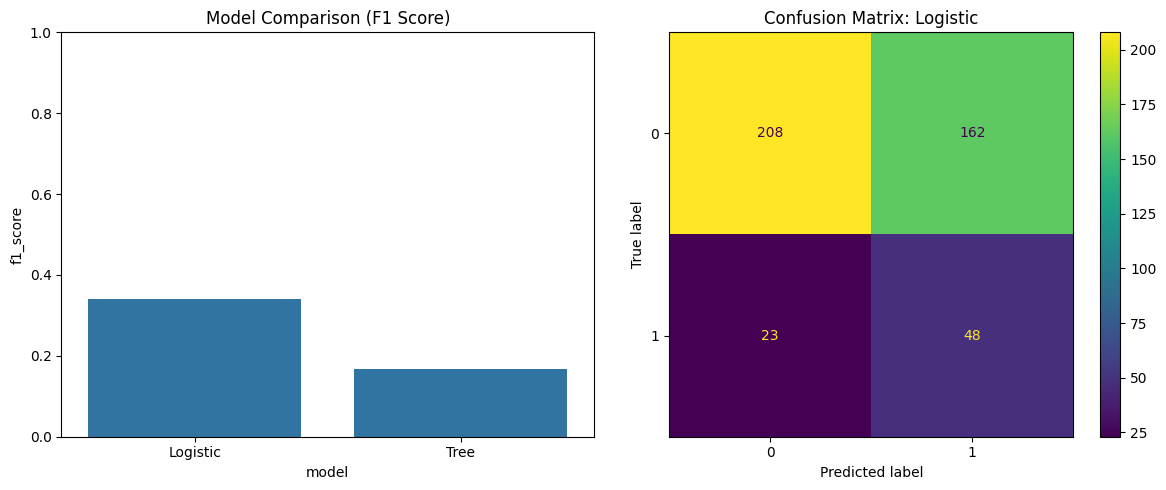

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, ConfusionMatrixDisplay

# Load data
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df["AttritionFlag"] = df["Attrition"].map({"Yes": 1, "No": 0})

X = df[["Age", "MonthlyIncome", "DistanceFromHome"]]
y = df["AttritionFlag"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models
models = {
    "Logistic": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Tree": DecisionTreeClassifier(class_weight="balanced")
}

results = []

# Train + evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    f1 = f1_score(y_test, pred)

    results.append((name, f1, model))
    print(name, "F1:", round(f1, 3))

# Get best model
best_name, best_score, best_model = max(results, key=lambda x: x[1])

print("\nBest Model:", best_name)
print("Best F1 Score:", round(best_score, 3))

# Convert for plotting
results_df = pd.DataFrame(results, columns=["model", "f1_score", "model_obj"])

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=results_df, x="model", y="f1_score", ax=ax[0])
ax[0].set_title("Model Comparison (F1 Score)")
ax[0].set_ylim(0, 1)

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, ax=ax[1])
ax[1].set_title(f"Confusion Matrix: {best_name}")

plt.tight_layout()
plt.show()